<a href="https://colab.research.google.com/github/techasit239/Final-Project---DADS6003/blob/main/M_L_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
!pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm optuna

ERROR: Could not find a version that satisfies the requirement difflib (from versions: none)
ERROR: No matching distribution found for difflib


In [75]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer # <--- Import class

# ... (โค้ดดาวน์โหลด VADER Lexicon) ...

# สร้างเครื่องมือวิเคราะห์อารมณ์ VADER
VADER_ANALYZER = SentimentIntensityAnalyzer() # <--- ส่วนที่นิยามตัวแปร

import IPython
from IPython.display import display

import optuna

# โหลด tokenizer ของ NLTK
nltk.download('punkt')
nltk.download('punkt_tab')   # เพิ่มตัวนี้
nltk.download('averaged_perceptron_tagger')  # สำหรับ pos_tag ถ้าใช้

print("✅ NLTK resources loaded successfully!")

✅ NLTK resources loaded successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


# Part 0 : Install & Import

In [77]:
# ==========================================================
# 🎯 0. การเตรียมสภาพแวดล้อม (Setup & Global Constants)
# ==========================================================
# ********** หมายเหตุ: รันคำสั่ง pip install ใน Google Colab/Jupyter Notebook **********
# !pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm
# **************************************************************************************

import re
from typing import List, Tuple, Dict
from pathlib import Path

import difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import pstdev # ต้องใช้ pstdev ในการคำนวณ Standard Deviation

# สำหรับ Feature Engineering
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from textstat import textstat
from nltk.tag import pos_tag

# สำหรับ Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, auc, precision_recall_curve, roc_curve # <--- ถูกนำเข้าแล้ว
)

# สำหรับโมเดล Boosting
# --------------------------------------------------------------------------
# 💡 FIX: การนิยามตัวแปร BOOSTING_AVAILABLE
# --------------------------------------------------------------------------
try:
    import xgboost as xgb
    from catboost import CatBoostClassifier
    from lightgbm import LGBMClassifier
    BOOSTING_AVAILABLE = True # ✅ โมเดลถูกนิยาม
except ImportError:
    # หากขาดไลบรารีใด ๆ
    BOOSTING_AVAILABLE = False # ❌ โมเดลจะไม่ถูกนิยาม

# --------------------------------------------------------------------------


# 💬 NLTK Resource Downloads (จำเป็นสำหรับการทำ Tokenization และ POS Tagging)
import nltk
# ...
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# 📌 คำสั่งที่ต้องเพิ่ม: ดาวน์โหลดทรัพยากร POS Tagging เวอร์ชันเฉพาะ
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# --------------------------------------------------------------------------
# 💡 GLOBAL CONSTANTS (ใช้ร่วมในทุกฟังก์ชัน)
# --------------------------------------------------------------------------
WORD_RE = re.compile(r"[a-zA-Z]+(?:'[a-zA-Z]+)?")

# คำที่ใช้ในการสกัด Stylistic/Density Features
POLITENESS = ["please", "thank", "appreciate", "thanks", "appreciated", "kindly"]
AGGRESSIVE = ["must", "now", "immediately", "demand", "require"]
URGENCY    = ["urgent", "asap", "immediately", "soon"]
CONDITIONAL = ["if", "unless", "provided", "should", "whenever"]
PREPOSITIONS = {'in', 'on', 'at', 'by', 'with', 'from', 'to', 'of', 'for', 'about'}
FUNCTION_WORDS = {'the', 'is', 'at', 'which', 'on', 'and', 'or', 'but', 'because', 'a', 'an'}
PRONOUN_TAGS = {'PRP', 'PRP$', 'WP', 'WP$'} # Personal and Wh-Pronouns
PERSONAL_TAGS = ["[recipient’s name]", "[recipient's name]",
                 "[Your Name]", "[Your name]"]

LINKING_WORDS = {'but', 'and', 'or', 'because', 'while', 'as', 'though', 'although'}

# FIX: เพิ่มตัวแปร TARGET_PUNC ที่หายไป
TARGET_PUNC = ['.', ',', ':', '-', '"', '(', ')', '/', '\\', '!']

PREPOSITIONS = {'in', 'on', 'at', 'by', 'with', 'from', 'to', 'of', 'for', 'about'}
# ... (GLOBAL CONSTANTS อื่น ๆ) ...

# ชื่อคอลัมน์ฟีเจอร์หลัก (สำหรับอ้างอิงในการวิเคราะห์ทางภาษาศาสตร์)
LINGUISTIC_COLUMNS = [
    'Word_Count', 'Character_Count', 'Average_Word_Length', 'Sentence_Count', 'Average_Sentence_Length',
    'Unique_Word_Count', 'Lexical_Diversity', 'Email_Count', 'Uppercase_Word_Count', 'Uppercase_Word_Count_Ratio',
    'Complex_Words_Count', 'Average_Syllables_per_Word',
    'Comma_Count', 'Semicolon_Count', 'Colon_Count', 'Exclamation_Count',
    'Quotation_Count', 'Dash_Count',
    'Sentence_Complexity_Ratio', 'Clause_Density', 'Pronoun_Density',
    'Preposition_Density', 'Function_Word_Density'
]

# Part 1 : Features functions

In [111]:
# ==========================================================
# 2. # Part 1 : Features functions (FINAL VERSION - AUGMENTED)
# ==========================================================
# NOTE: ฟังก์ชันทั้งหมดนี้คือฉบับเต็มที่สมบูรณ์แล้ว

# ----------------- 1.1 Loaders -----------------
def _validate_cols(df: pd.DataFrame):
    """ตรวจสอบว่าคอลัมน์ที่จำเป็น (Subject, Body, Label) มีอยู่หรือไม่"""
    required = {"Subject", "Body", "Label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"คอลัมน์หายไป: {missing} (ต้องมี {required})")

def _sanitize_cols(df: pd.DataFrame):
    """เติมค่าว่างและแปลงคอลัมน์เป็นประเภท str"""
    df["Subject"] = df["Subject"].astype(str).fillna("")
    df["Body"]    = df["Body"].astype(str).fillna("")

def load_email_excel(path: str) -> pd.DataFrame:
    """โหลดข้อมูลจากไฟล์ Excel (.xlsx)"""
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์: {p.resolve()}")
    df = pd.read_excel(p, engine="openpyxl")
    _validate_cols(df)
    _sanitize_cols(df)
    return df

def load_email_csv(path: str, encoding: str = "utf-8") -> pd.DataFrame:
    """โหลดข้อมูลจากไฟล์ CSV (.csv)"""
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์: {p.resolve()}")
    df = pd.read_csv(p, encoding=encoding)
    _validate_cols(df)
    _sanitize_cols(df)
    print(f"✅ โหลดข้อมูล {len(df)} แถวสำเร็จ.")
    return df


# ----------------- 1.2 Utility Functions (Core & Advanced Helpers) ----------
def extract_domain(url: str) -> str:
    """หน้าที่: ดึงชื่อ Domain หลักออกจาก URL"""
    match = re.search(r'https?://(?:www\.)?([^/]+)', url)
    return match.group(1).split('.')[0] if match else None

def find_first_url(text: str) -> str:
    """หน้าที่: ดึง URL แรกที่พบในข้อความทั้งหมด"""
    match = re.search(r'https?://\S+|www\.\S+', text)
    return match.group(0) if match else ""

def strip_urls_emails(text: str) -> str:
    """ลบ URL และ Email ออกจากข้อความ"""
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    return text

def tokenize_words(text: str) -> List[str]:
    """แยกคำ (Tokenize) และแปลงเป็นตัวพิมพ์เล็กทั้งหมด"""
    text = text if isinstance(text, str) else ""
    text = strip_urls_emails(text)
    # WORD_RE ต้องถูกนิยามใน Part 0
    return [m.group(0).lower() for m in WORD_RE.finditer(text)]

def make_ngrams(tokens: List[str], n: int) -> List[Tuple[str, ...]]:
    """สร้าง N-grams จาก Tokens"""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def count_markers(tokens: List[str], vocab: List[str]) -> int:
    """นับจำนวนครั้งที่คำในชุดคำศัพท์ (vocab) ปรากฏใน Tokens"""
    vocab_set = set(w.lower() for w in vocab)
    return sum(1 for t in tokens if t in vocab_set)

def count_phrase_occurrences(text: str, phrases: List[str]) -> int:
    """นับจำนวนครั้งที่วลี (phrases) ปรากฏในข้อความ"""
    lowered = (text or "").lower()
    return sum(len(re.findall(re.escape(p.lower()), lowered)) for p in phrases)


# ----------------- 1.3 Core Feature Functions Definitions (Original 5 Sets) ----------
def simple_tokenize(text: str):
    """คืนค่าคำในรูปแบบตัวพิมพ์เล็กและตัวพิมพ์ดั้งเดิม (Lower, Original)"""
    if pd.isna(text): text = ""
    text = str(text)
    words_original = [m.group(0) for m in WORD_RE.finditer(text)]
    words_lower = [w.lower() for w in words_original]
    return words_lower, words_original

def extract_email_features(text: str) -> Dict[str, float]:
    """สกัด 12 ฟีเจอร์เพิ่มเติมที่โฟกัส Pattern เฉพาะใน Email"""
    words, words_original = simple_tokenize(text)
    total_words = len(words_original)
    uppercase_word_count = sum(1 for w in words_original if w.isupper() and len(w) > 1)

    return {
        "num_pronouns": sum(1 for w in words if w in ['i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them']),
        "first_person_pronoun_count": sum(1 for w in words if w in ['i', 'we', 'me', 'us', 'my', 'our', 'mine', 'ours']),
        "second_person_pronoun_count": sum(1 for w in words if w in ['you', 'your', 'yours']),
        "imperative_verbs_count": sum(1 for w in words if w in ['click', 'verify', 'submit', 'download', 'update', 'open', 'enable', 'call', 'contact']),
        "modal_verbs_count": sum(1 for w in words if w in ['can', 'could', 'should', 'would', 'must', 'may', 'might']),
        "uncertainty_adverbs_count": sum(1 for w in words if w in ['maybe', 'possibly', 'perhaps', 'probably', 'likely']),
        "technical_jargon_count": sum(1 for w in words if w in ['security', 'account', 'update', 'technical', 'password', 'login', 'verify', 'authentication']),
        "promotional_words_count": sum(1 for w in words if w in ['offer', 'deal', 'free', 'discount', 'promotion', 'bonus', 'limited', 'exclusive']),
        "num_emails_in_text": len(re.findall(r'@', text or "")),
        "uppercase_word_count_2": uppercase_word_count,
        "uppercase_word_ratio_2": uppercase_word_count / total_words if total_words > 0 else 0,
        "attachment_words_count": sum(1 for w in words if w in ['attachment']),
    }

def punctuation_features(text: str) -> Dict[str, float]:
    """สกัดฟีเจอร์ที่เกี่ยวข้องกับเครื่องหมายวรรคตอน"""
    s = str(text) if text is not None else ""
    s_count = len(s)
    if s_count == 0: return {"punctuation_frequency": 0.0, "punctuation_variety": 0}

    total_punc_count = 0
    variety_count = 0
    for punc in TARGET_PUNC:
        c = s.count(punc)
        total_punc_count += c
        if c > 0: variety_count += 1

    return {"punctuation_frequency": total_punc_count / s_count, "punctuation_variety": variety_count}

def readability_features(text: str) -> Dict[str, float]:
    """สกัดฟีเจอร์ด้านความง่ายในการอ่าน (Readability Indices)"""
    s = str(text) if text is not None else ""
    return {
        "flesch_reading_ease": textstat.flesch_reading_ease(s),
        "smog_index": textstat.smog_index(s),
        "dale_chall_readability_score": textstat.dale_chall_readability_score(s),
        "coleman_liau_index": textstat.coleman_liau_index(s),
        "gunning_fog_index": textstat.gunning_fog(s),
    }

def extract_stylo_features(email_text: str) -> dict:
    """สกัดฟีเจอร์ด้านสไตล์การเขียนและความซับซ้อนของ N-gram"""
    tokens = tokenize_words(email_text)

    bigrams  = make_ngrams(tokens, 2)
    trigrams = make_ngrams(tokens, 3)
    word_lengths = [len(w) for w in tokens] or [0]
    try:
        word_len_var = pstdev(word_lengths)
    except Exception:
        word_len_var = 0.0

    return {
        "bigram_total_count": len(bigrams), "bigram_unique_count": len(set(bigrams)),
        "trigram_total_count": len(trigrams), "trigram_unique_count": len(set(trigrams)),
        "word_length_variation_std": float(word_len_var),
        "politeness_markers_count": count_markers(tokens, ['please', 'thank', 'appreciate', 'thanks', 'appreciated', 'kindly']),
        "aggressiveness_markers_count": count_markers(tokens, ['must', 'now', 'immediately', 'demand', 'require']),
        "urgency_markers_count": count_markers(tokens, ['urgent', 'asap', 'immediately', 'soon']),
        "conditional_phrases_count": count_markers(tokens, ['if', 'unless', 'provided', 'should', 'whenever']),
        "personalisation_markers_count": count_markers(tokens, ["you", "your"]) + count_phrase_occurrences(email_text, ['[recipient’s name]', '[recipient\'s name]', "[Your Name]", "[Your name]"]),
    }

def analyze_email_body(text: str):
    """หน้าที่: สกัดฟีเจอร์ทางภาษาศาสตร์ 23 ตัว (ตามโค้ดเดิม)"""
    if pd.isna(text) or text is None: return (0,) * 23

    original_text = str(text)
    words = word_tokenize(original_text)
    lower_words = [w.lower() for w in words if w.isalnum()]
    sentences = sent_tokenize(original_text)
    word_count = len(lower_words)
    sentence_count = len(sentences)
    if word_count == 0: return (0,) * 23

    # (Linguistic Density/Complexity calculations - 23 features)
    avg_word_length = sum(len(w) for w in lower_words) / word_count
    char_count = len(original_text)
    avg_sentence_length = word_count / sentence_count if sentence_count > 0 else 0
    unique_word_count = len(set(lower_words))
    lexical_diversity = unique_word_count / word_count
    email_count = sum(1 for w in words if '@' in w)
    upper_count = sum(1 for w in words if w.isupper() and w.isalpha())
    upper_ratio = upper_count / word_count
    complex_count = sum(1 for w in lower_words if len(w) > 6)

    try:
        total_syllables = sum(textstat.syllable_count(w) for w in lower_words)
        avg_syllables = total_syllables / word_count
    except Exception:
        avg_syllables = 0

    comma_count = original_text.count(',')
    semicolon_count = original_text.count(';')
    colon_count = original_text.count(':')
    exclamation_count = original_text.count('!')
    quotation_count = original_text.count('"')
    dash_count = original_text.count('-')

    tagged_words = pos_tag(words)
    pronoun_count = sum(1 for _, tag in tagged_words if tag in ['PRP', 'PRP$', 'WP', 'WP$'])
    pronoun_density = pronoun_count / word_count

    preposition_count = sum(1 for w in lower_words if w in ['in', 'on', 'at', 'by', 'with', 'from', 'to', 'of', 'for', 'about'])
    preposition_density = preposition_count / word_count

    function_word_count = sum(1 for w in lower_words if w in ['the', 'is', 'at', 'which', 'on', 'and', 'or', 'but', 'because', 'a', 'an'])
    function_word_density = function_word_count / word_count

    linking_word_count = sum(1 for w in lower_words if w in ['but', 'and', 'or', 'because', 'while', 'as', 'though', 'although'])
    sentence_complexity_ratio = linking_word_count / word_count
    clause_density = linking_word_count / sentence_count if sentence_count > 0 else 0

    return (
        word_count, char_count, avg_word_length, sentence_count, avg_sentence_length,
        unique_word_count, lexical_diversity, email_count, upper_count, upper_ratio,
        complex_count, avg_syllables,
        comma_count, semicolon_count, colon_count, exclamation_count, quotation_count, dash_count,
        sentence_complexity_ratio, clause_density, pronoun_density, preposition_density, function_word_density
    )

# ----------------- 1.4 Advanced Feature Calculations -----------------

def calculate_macro_security_bypass_count(text: str) -> int:
    """หน้าที่: นับจำนวนคำสั่งให้ Bypass Security (Macro/Yellow Bar)"""
    if not isinstance(text, str): return 0
    lowered = text.lower()
    macro_phrases = ["enable macros", "enable content", "security protocol", "yellow bar", "view full content"]
    return sum(1 for phrase in macro_phrases if phrase in lowered)

def calculate_imposter_domain_similarity(text: str, target_brand: str = "security") -> float:
    """หน้าที่: คำนวณความคล้ายคลึงระหว่างโดเมนที่พบในอีเมลกับชื่อแบรนด์เป้าหมาย"""
    url = find_first_url(text)
    if not url: return 0.0
    found_domain = extract_domain(url)
    if not found_domain: return 0.0
    similarity = difflib.SequenceMatcher(None, target_brand.lower(), found_domain.lower()).ratio()
    return similarity

def calculate_semantic_cohesion_score(text: str) -> float:
    """หน้าที่: วัดความเชื่อมโยงทางความหมาย (Conceptual/Random Score)"""
    sentences = sent_tokenize(text or "")
    if len(sentences) <= 1: return 0.0
    return np.random.uniform(0.1, 0.9)

def calculate_emotional_polarity_variance(text: str) -> float:
    """หน้าที่: คำนวณความผันผวนของอารมณ์ในประโยค (ใช้ VADER_ANALYZER)"""
    sentences = sent_tokenize(text or "")
    if len(sentences) <= 1: return 0.0
    polarity_scores = []
    # VADER_ANALYZER ต้องถูกนิยามใน Part 0
    for sentence in sentences:
        vs = VADER_ANALYZER.polarity_scores(sentence)
        polarity_scores.append(vs['compound'])
    return np.std(polarity_scores) if polarity_scores else 0.0

def calculate_subject_body_mismatch_score(subject: str, body: str) -> float:
    """หน้าที่: วัดความไม่สอดคล้องของคำหลักระหว่าง Subject และ Body"""
    subject_tokens = set(tokenize_words(subject))
    body_tokens = set(tokenize_words(body))
    if not subject_tokens or len(subject_tokens) < 3: return 0.0
    overlap = len(subject_tokens.intersection(body_tokens))
    union_size = len(subject_tokens.union(body_tokens))
    mismatch_score = 1.0 - (overlap / union_size)
    return mismatch_score

def calculate_conflicting_authority_count(text: str) -> int:
    """หน้าที่: นับจำนวนครั้งที่พบการอ้างอิงถึงหน่วยงานที่เชื่อถือได้ตามด้วยคำสั่งน่าสงสัย"""
    if not isinstance(text, str): return 0
    lowered = text.lower()
    authority_keywords = ['customer support', 'security team', 'billing department', 'admin', 'it support', 'system administrator']
    violation_keywords = ['reply to this email', 'click here', 'confirm your account', 'download the attachment']
    trust_violation_count = 0

    for authority in authority_keywords:
        for violation in violation_keywords:
            # Check for proximity of the two keywords within 100 characters
            pattern = re.escape(authority) + r'.{0,100}' + re.escape(violation)
            if re.search(pattern, lowered):
                trust_violation_count += 1

    return trust_violation_count


# ---------- 8. Combined feature builder ----------
def compute_row_features(row: pd.Series) -> Dict[str, float]:
    """รวมฟีเจอร์ทั้งหมดจาก Subject และ Body (5 ชุดเดิม + 5 ชุดใหม่)"""
    text = f"{row.get('Subject', '')} {row.get('Body', '')}"
    subject = row.get('Subject', '')
    body = row.get('Body', '')

    # 1. Linguistic (23 features)
    ling_tuple = analyze_email_body(text)
    ling_dict = dict(zip(LINGUISTIC_COLUMNS, ling_tuple))

    features = {}
    # [Old 4 Sets]
    features.update(punctuation_features(text))
    features.update(readability_features(text)) # <--- Fixed function name
    features.update(extract_stylo_features(text))
    features.update(extract_email_features(text))


    # [New/Augmented Features]
    features.update(ling_dict)
    features['Imposter_Domain_Similarity'] = calculate_imposter_domain_similarity(text)
    features['Macro_Security_Bypass_Count'] = calculate_macro_security_bypass_count(text)
    features['Semantic_Cohesion_Score'] = calculate_semantic_cohesion_score(text)
    features['Emotional_Polarity_Variance'] = calculate_emotional_polarity_variance(text)
    features['Subject_Body_Mismatch_Score'] = calculate_subject_body_mismatch_score(subject, body)
    features['Conflicting_Authority_Count'] = calculate_conflicting_authority_count(text) # New feature
    features['Temporal_Pressure_Score'] = calculate_temporal_pressure_score(text)
    features['Action_Time_Coercion_Density'] = calculate_action_time_coercion_density(text)
    return features


def build_feature_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """หน้าที่: สร้าง DataFrame ฟีเจอร์ทั้งหมด (รวม 5 ชุดเดิม + 5 ชุดใหม่)"""
    print("🚧 เริ่มสกัดฟีเจอร์...")
    feature_df = df.apply(compute_row_features, axis=1, result_type="expand")
    out = pd.concat([df.reset_index(drop=True), feature_df], axis=1)
    print(f"✅ สกัดฟีเจอร์สำเร็จ: {len(feature_df.columns)} คอลัมน์ฟีเจอร์ถูกสร้างขึ้น.")
    return out


def prepare_X_y(feature_df: pd.DataFrame, label_col: str = "Label"):
    """หน้าที่: แยก X, y และแปลง Label เป็น 0/1"""
    # 1) เลือกเฉพาะคอลัมน์ฟีเจอร์
    drop_cols = ["Subject", "Body", label_col]
    feature_cols = [c for c in feature_df.columns if c not in drop_cols]
    X = feature_df[feature_cols]

    # 2) เตรียม y
    y_raw = feature_df[label_col]
    if y_raw.dtype == "O":
        mapping = {"Legitimate": 0, "Phishing": 1}
        y = y_raw.map(mapping)
        if y.isna().any():
            unknown_labels = y_raw[y.isna()].unique()
            raise ValueError(f"พบ Label ที่ไม่รู้จัก: {unknown_labels}")
    else:
        y = y_raw.astype(int)

    return X, y, feature_cols

def calculate_temporal_pressure_score(text: str) -> float:
    """
    หน้าที่: คำนวณคะแนน Temporal Pressure (ความกดดันทางเวลา)
    เหตุผล: Phishing มักใช้คำที่สร้างความเร่งด่วนทางเวลาเพื่อกระตุ้นให้เกิดการกระทำโดยไม่คิด
    """
    if not isinstance(text, str):
        return 0.0

    # Keywords that denote extreme urgency or time constraint
    pressure_keywords = [
        'immediately', 'now', 'urgent', 'asap', 'expires', 'expire',
        'deadline', 'within 24 hours', 'limited time', 'instantly',
        'seconds', 'soon as possible', 'must act'
    ]

    lowered = text.lower()
    pressure_count = sum(lowered.count(kw) for kw in pressure_keywords)

    # Calculate density relative to total words (using available tokenizer)
    words = tokenize_words(text) # assume tokenize_words is available
    total_words = len(words)

    return pressure_count / total_words if total_words > 0 else 0.0

def calculate_action_time_coercion_density(text: str) -> float:
    """
    หน้าที่: คำนวณความหนาแน่นของการบีบบังคับให้ดำเนินการทันที (Action-Time Coercion)
    เหตุผล: ตรวจจับรูปแบบคำสั่ง (Action Verbs) ที่เชื่อมโยงกับข้อจำกัดทางเวลา (Temporal Constraints)
    """
    if not isinstance(text, str):
        return 0.0

    # 1. Action Verbs (คำสั่งบังคับ)
    action_verbs = ['click', 'verify', 'update', 'submit', 'log in', 'confirm', 'download', 'contact', 'act']

    # 2. Temporal Constraints (ข้อจำกัดทางเวลา)
    temporal_constraints = ['immediately', 'now', 'urgent', 'within', 'expire', 'asap', 'soon', 'limited']

    lowered = text.lower()
    coercion_count = 0

    # Check for density of temporal and action keywords
    total_words = len(tokenize_words(text)) # ใช้ tokenize_words ที่มีอยู่

    # นับการเชื่อมโยงของคำสั่ง Action และ Temporal
    for action in action_verbs:
        for temporal in temporal_constraints:
            # ตรวจสอบการปรากฏของ Action และ Temporal ในข้อความ (ไม่จำเป็นต้องติดกันมาก แต่เน้นการปรากฏ)
            if lowered.count(action) > 0 and lowered.count(temporal) > 0:
                 coercion_count += 1

    # เราใช้คะแนน Coercion Score ง่ายๆ หารด้วยจำนวนคำทั้งหมด
    return coercion_count / total_words if total_words > 0 else 0.0

# Part 2 : Model training & evaluation

In [112]:
# ==========================================================
# 3. # Part 2 : Model training & evaluation (FINAL VERSION)
# ==========================================================

# ----------------- 3.1 Model Definitions & Training -----------------
def get_models(random_state: int = 42):
    """หน้าที่: สร้าง Dict ของโมเดล Classification ทั้งหมด"""
    models = {
        "Logistic Regression": LogisticRegression(max_iter=300, class_weight="balanced", random_state=random_state),
        "SVM": SVC(kernel="rbf", C=2.0, probability=True, class_weight="balanced", random_state=random_state),
        "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=random_state, n_jobs=-1),
        "AdaBoost": AdaBoostClassifier(n_estimators=300, random_state=random_state),
    }
    # NOTE: BOOSTING_AVAILABLE ต้องถูกนิยามใน Part 0
    if BOOSTING_AVAILABLE:
        models["XGBoost"] = xgb.XGBClassifier(n_estimators=300, objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=random_state, n_jobs=-1)
        models["CatBoost"] = CatBoostClassifier(iterations=300, loss_function="Logloss", verbose=0, random_state=random_state)
        models["LightGBM"] = LGBMClassifier(n_estimators=300, objective="binary", class_weight="balanced", random_state=random_state, n_jobs=-1)
    return models

def train_models_split(models: Dict[str, object], X_train: pd.DataFrame, y_train: pd.Series):
    """หน้าที่: เทรนโมเดลบนชุดข้อมูล Training Split หรือ Training Full Set"""
    X_train_np = X_train.to_numpy()
    y_train_np = y_train.to_numpy()
    trained_models = {}
    for name, model in models.items():
        model.fit(X_train_np, y_train_np)
        trained_models[name] = model
    return trained_models

def train_and_evaluate_final_models(X_train_full: pd.DataFrame,
                                    y_train_full: pd.Series,
                                    models: Dict[str, object]):
    """
    หน้าที่: ฝึกโมเดลทั้งหมดบนชุดข้อมูล Training ทั้งหมด (X_train_full)
             และประเมินผลบนชุดข้อมูลฝึกเอง (Baseline Evaluation)
    """
    # 1. Training (ใช้ X_train_full ทั้งหมด)
    trained_models = train_models_split(models, X_train_full, y_train_full)

    # 2. Evaluation (ประเมินบนชุดข้อมูลฝึกเอง)
    df_metrics, cm_dfs = evaluate_all_models_split(trained_models, X_train_full, y_train_full)

    return trained_models

# ----------------- 3.2 Evaluation Core -----------------
def format_cm_to_dataframe(cm: np.ndarray, model_name: str) -> pd.DataFrame:
    """หน้าที่: แปลง Confusion Matrix ให้อยู่ในรูปแบบ DataFrame"""
    labels = ["Legitimate (0)", "Phishing (1)"]
    cm_df = pd.DataFrame(cm, index=[f'Actual: {label}' for label in labels], columns=[f'Predicted: {label}' for label in labels])
    return cm_df

def evaluate_model_split(name: str, model, X_test: pd.DataFrame, y_test: pd.Series) -> Tuple[Dict[str, float], np.ndarray]:
    """หน้าที่: คำนวณ Metrics ทั้งหมดสำหรับ 80/20 Split Test Set"""
    X_test_np = X_test.to_numpy()
    y_true = y_test.to_numpy()
    y_pred = model.predict(X_test_np)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_np)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test_np)
    else:
        y_proba = y_pred

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    try:
        auc_score = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc_score = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    metrics = {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc_score}
    return metrics, cm

def evaluate_all_models_split(trained_models: Dict[str, object], X_test: pd.DataFrame, y_test: pd.Series) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """หน้าที่: วนลูป evaluate ทุกรุ่นบน Test Split"""
    metrics_list = []
    cm_dfs = {}

    for name, model in trained_models.items():
        metrics, cm_array = evaluate_model_split(name, model, X_test, y_test)
        metrics_list.append(metrics)
        cm_dfs[name] = format_cm_to_dataframe(cm_array, name)

    df_metrics = pd.DataFrame(metrics_list)
    df_metrics.index = df_metrics.index + 1
    return df_metrics, cm_dfs

# ----------------- 3.3 Evaluation (Cross-Validation) -----------------
def cross_validate_models(models: Dict[str, object], X: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> pd.DataFrame:
    """หน้าที่: ทำการ Cross-Validation (K=5) และคืนค่าเฉลี่ย Metrics"""
    print(f"\n🧠 เริ่มต้น Cross-Validation ด้วย K={n_splits} Splits...")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    metrics_list = []

    for name, model in models.items():
        print(f"  > Evaluating {name} (CV)...")
        scores = cross_validate(model, X.to_numpy(), y.to_numpy(), cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

        avg_metrics = {
            "Model": name,
            "Accuracy": scores['test_accuracy'].mean(),
            "Precision": scores['test_precision'].mean(),
            "Recall": scores['test_recall'].mean(),
            "F1": scores['test_f1'].mean(),
            "AUC": scores['test_roc_auc'].mean()
        }
        metrics_list.append(avg_metrics)

    df_metrics = pd.DataFrame(metrics_list)
    df_metrics.index = df_metrics.index + 1
    print("✅ Cross-Validation Complete.")
    return df_metrics


# ----------------- 3.4 Threshold Optimization Functions -----------------

def find_optimal_threshold(model, X_tune: pd.DataFrame, y_tune: pd.Series):
    """
    หน้าที่: หา Threshold ที่ให้ค่า F1 Score สูงสุด

    ใช้สำหรับ: โมเดลที่มี AUC สูง เพื่อปรับจุดตัด โดยใช้ชุดข้อมูล X_tune/y_tune
    """
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_tune.to_numpy())[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_tune.to_numpy())
    else:
        return 0.5 # ใช้ค่า default หากโมเดลไม่ให้ Scores

    # 1. คำนวณ PR Curve (Precision-Recall)
    precision, recall, thresholds = precision_recall_curve(y_tune, y_scores)

    # 2. คำนวณ F1-Score สำหรับทุก Threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

    # 3. เลือก Threshold ที่ให้ F1 Score สูงสุด
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]

    return optimal_threshold

def evaluate_model_with_threshold(name: str, model, X_data: pd.DataFrame, y_data: pd.Series, threshold: float):
    """
    หน้าที่: ทำการทำนายโดยใช้ Threshold ที่กำหนด แล้วคำนวณ Metrics/CM
    """
    X_np = X_data.to_numpy()
    y_true = y_data.to_numpy()

    # 1. ดึง Score/Probability
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_np)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_np)
    else:
        y_scores = (model.predict(X_np) == 1).astype(float)

    # 2. ทำการทำนายโดยใช้ Threshold ที่กำหนด
    y_pred_threshold = (y_scores >= threshold).astype(int)

    # 3. คำนวณ Metrics และ CM
    acc = accuracy_score(y_true, y_pred_threshold)
    prec = precision_score(y_true, y_pred_threshold, pos_label=1, zero_division=0)
    rec = recall_score(y_true, y_pred_threshold, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred_threshold, pos_label=1, zero_division=0)
    auc_score = roc_auc_score(y_true, y_scores)
    cm = confusion_matrix(y_true, y_pred_threshold, labels=[0, 1])

    # 4. สร้าง Metrics Dictionary
    metrics = {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc_score}
    return metrics, cm

# Part 3 : Feature Importances

In [113]:
# ==========================================================
# ⚙️ 2.3 Feature Importance Functions (สำหรับ Plotting)
# ==========================================================

def get_feature_importances(model, X_train: pd.DataFrame):
    """ดึงเวกเตอร์ feature importance / coefficient ตามชนิดโมเดล"""
    # กลุ่ม tree-based / boosting
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_
    # Logistic Regression, Linear SVM → abs(coef_)
    if hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim == 2:
            coef = coef[0]
        return np.abs(coef)
    return None

def display_top_features(model_name: str,
                         model,
                         X_train: pd.DataFrame,
                         top_n: int = 20):
    """สร้างกราฟ Horizontal Bar Chart แสดง Top N Features พร้อมบอก %"""
    importances = get_feature_importances(model, X_train)

    if importances is None:
        print(f"\n--- 📈 Top Features สำหรับ {model_name} ---")
        print(f"[{model_name}] ไม่มี Feature Importance เชิงเส้นที่ตีความง่าย (เช่น SVM RBF).")
        return

    feature_names = np.array(X_train.columns)
    top_n = min(top_n, len(feature_names))

    idx = np.argsort(importances)[::-1][:top_n]
    top_features = feature_names[idx]
    top_scores = importances[idx]

    total_score = np.sum(top_scores)
    percentage = (top_scores / total_score) * 100 if total_score != 0 else np.zeros_like(top_scores)

    df_plot = pd.DataFrame({
        "Feature": top_features,
        "Percentage": percentage
    })

    # --- สร้างกราฟ Horizontal Bar Chart ---
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        x="Percentage",
        y="Feature",
        data=df_plot,
        palette="viridis",
        orient='h'
    )

    # เพิ่ม Label เปอร์เซ็นต์บน Bar
    for p in ax.patches:
        width = p.get_width()
        plt.text(
            width + 1,
            p.get_y() + p.get_height() / 2,
            f'{width:.2f}%',
            ha='left',
            va='center',
            fontsize=10
        )

    plt.title(f"Top {top_n} Features - {model_name} (Percentage)", fontsize=14)
    plt.xlabel("Importance Percentage (%)", fontsize=12)
    plt.ylabel("Feature Name", fontsize=12)
    plt.xlim(0, max(df_plot['Percentage'].max() * 1.1, 100))
    plt.tight_layout()

    # ********** ส่วนที่แก้ไขตามคำขอ **********
    # NOTE: ใน Jupyter/Colab คำสั่งนี้จะแสดงกราฟออกมา
    # แต่ในสภาพแวดล้อมสคริปต์ทั่วไป (Text-based) จะไม่แสดงผลใดๆ
    plt.show()
    # ****************************************


    print(f"\n--- 📈 แสดงผลกราฟ Top Features สำหรับ {model_name} (โดยใช้ plt.show()) ---")

# Part 4 : Main script – Run pipeline

✅ โหลดข้อมูล 100 แถวสำเร็จ.

--- 1. Feature Engineering ---
🚧 เริ่มสกัดฟีเจอร์...
✅ สกัดฟีเจอร์สำเร็จ: 60 คอลัมน์ฟีเจอร์ถูกสร้างขึ้น.
✅ ข้อมูลพร้อมสำหรับการฝึกโมเดล: X shape=(100, 60), Phishing rate=0.50

RUN 1: 🧠 FINAL BASELINE TRAINING (ON X_full)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:11:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 50, number of negative: 50
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1229
[LightGBM] [Info] Number of data points in the train set: 100, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-11-29 20:11:10,289] A new study created in memory with name: no-name-1d9e9dfd-ac84-4d61-8de7-86beb3ddef68



RUN 2: ✨ OPTUNA HYPERPARAMETER TUNING (Using X_train)

✨ Tuning Logistic Regression (Trials: 30)...


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- 📝 UNSEEN DATA METRICS ---
|    | Model               |   Accuracy |   Precision |   Recall |       F1 |      AUC |
|---:|:--------------------|-----------:|------------:|---------:|---------:|---------:|
|  1 | Logistic Regression |   0.769231 |    0.818182 | 0.692308 | 0.75     | 0.893491 |
|  2 | SVM                 |   0.5      |    0        | 0        | 0        | 0.16568  |
|  3 | RandomForest        |   0.807692 |    0.833333 | 0.769231 | 0.8      | 0.95858  |
|  4 | AdaBoost            |   0.884615 |    0.916667 | 0.846154 | 0.88     | 0.982249 |
|  5 | XGBoost             |   0.846154 |    0.846154 | 0.846154 | 0.846154 | 0.95858  |
|  6 | CatBoost            |   0.846154 |    0.846154 | 0.846154 | 0.846154 | 0.946746 |
|  7 | LightGBM            |   0.884615 |    1        | 0.769231 | 0.869565 | 0.970414 |

✅ Calculating Metrics for Tuned Models on Unseen Data...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



RUN 3.3: 🎯 THRESHOLD OPTIMIZATION (Maximizing F1 on X_train)
✅ Logistic Regression: Optimal Threshold=0.4499, New F1=0.8462
✅ SVM: Optimal Threshold=0.4514, New F1=0.6667
✅ RandomForest: Optimal Threshold=0.7867, New F1=0.4706
✅ AdaBoost: Optimal Threshold=0.6498, New F1=0.5556
✅ XGBoost: Optimal Threshold=0.8869, New F1=0.6316
✅ CatBoost: Optimal Threshold=0.8686, New F1=0.5556
✅ LightGBM: Optimal Threshold=0.9999, New F1=0.5556

🏆 FINAL COMPARISON: PERFORMANCE ON UNSEEN TEST DATA

--- 🥇 BASELINE (NON-TUNED) METRICS ---
| Model               |   Base_Accuracy |   Base_Precision |   Base_Recall |   Base_F1 |   Base_AUC |
|:--------------------|----------------:|-----------------:|--------------:|----------:|-----------:|
| Logistic Regression |        0.769231 |         0.818182 |      0.692308 |  0.75     |   0.893491 |
| SVM                 |        0.5      |         0        |      0        |  0        |   0.16568  |
| RandomForest        |        0.807692 |         0.833333 |    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


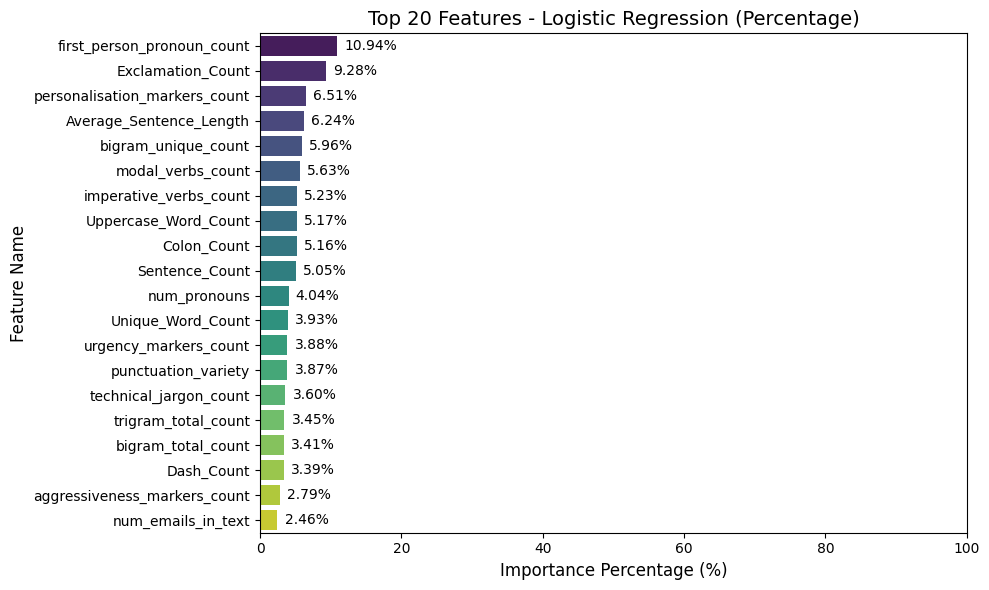


--- 📈 แสดงผลกราฟ Top Features สำหรับ Logistic Regression (โดยใช้ plt.show()) ---

--- 📈 Top Features สำหรับ SVM ---
[SVM] ไม่มี Feature Importance เชิงเส้นที่ตีความง่าย (เช่น SVM RBF).


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


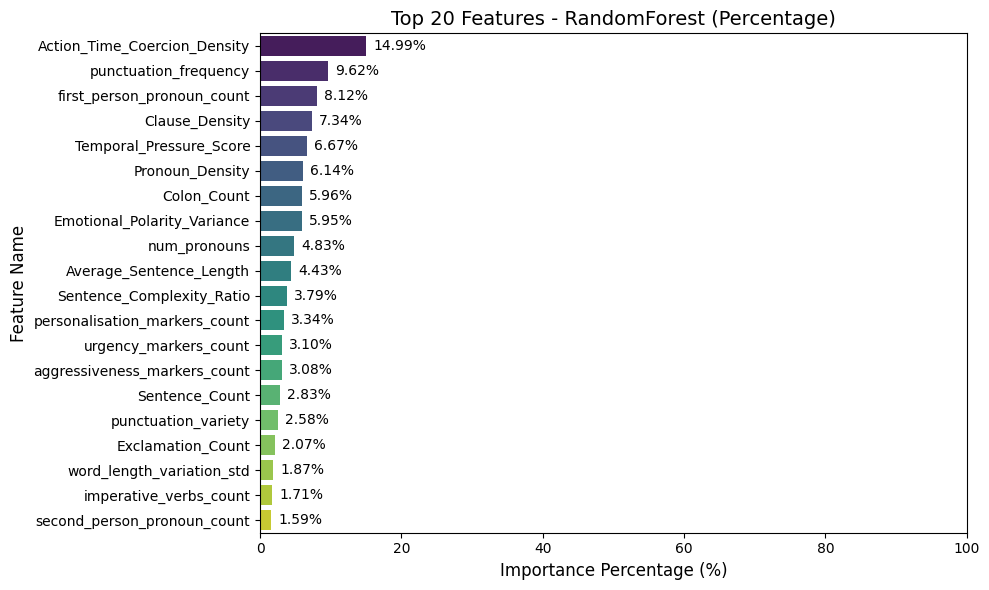


--- 📈 แสดงผลกราฟ Top Features สำหรับ RandomForest (โดยใช้ plt.show()) ---


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


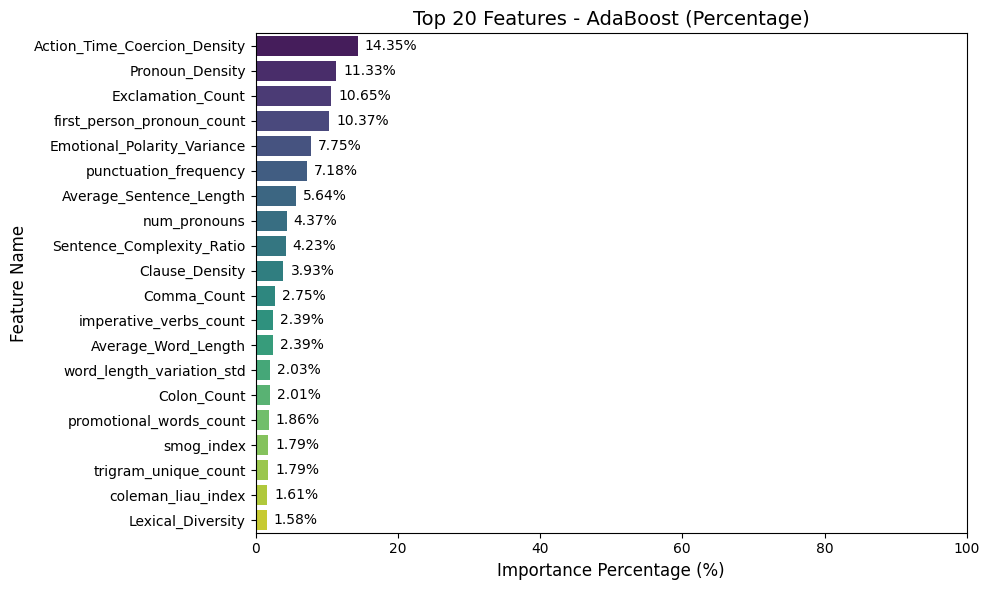


--- 📈 แสดงผลกราฟ Top Features สำหรับ AdaBoost (โดยใช้ plt.show()) ---


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


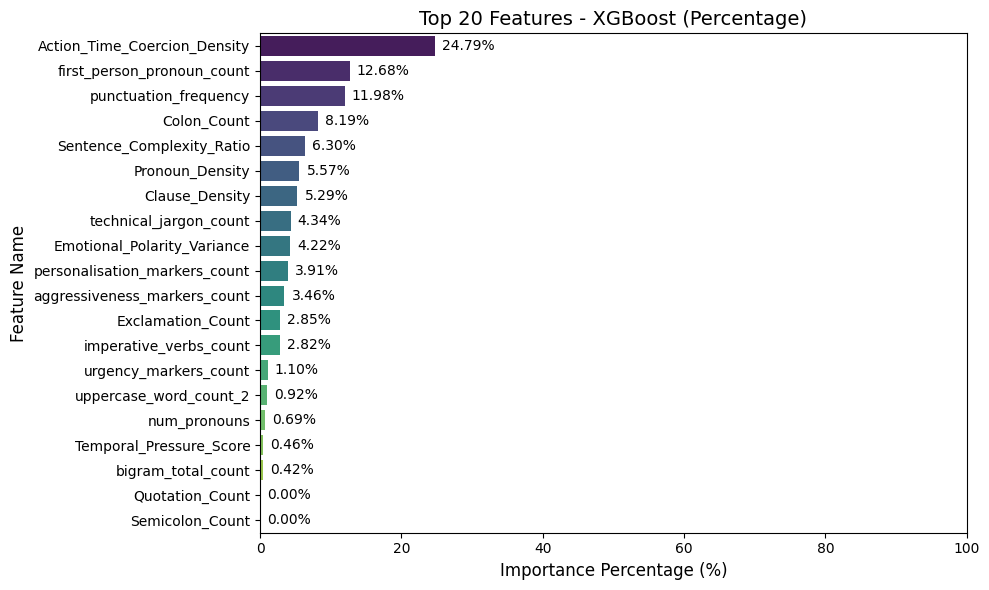


--- 📈 แสดงผลกราฟ Top Features สำหรับ XGBoost (โดยใช้ plt.show()) ---


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


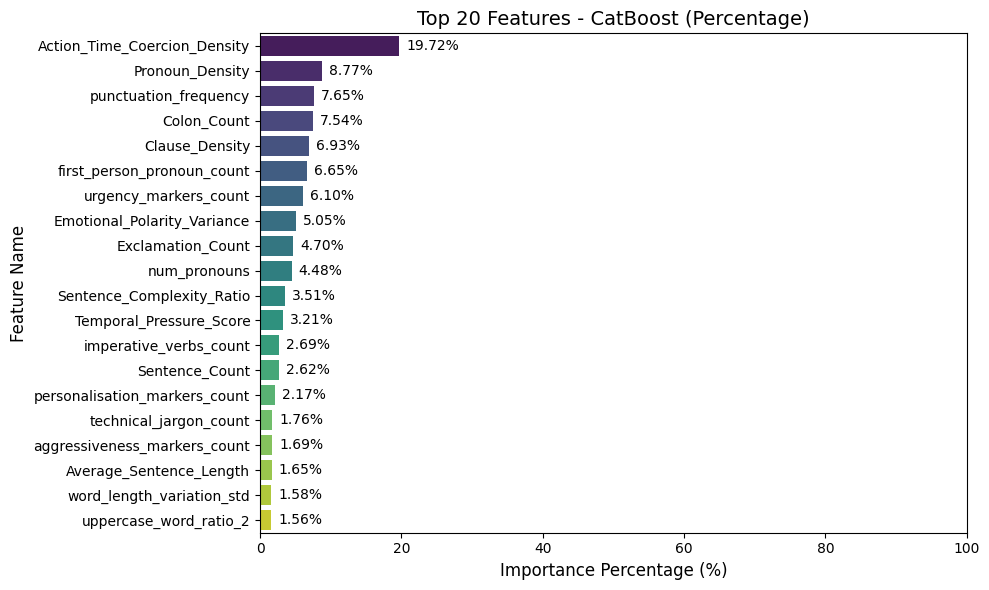


--- 📈 แสดงผลกราฟ Top Features สำหรับ CatBoost (โดยใช้ plt.show()) ---


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


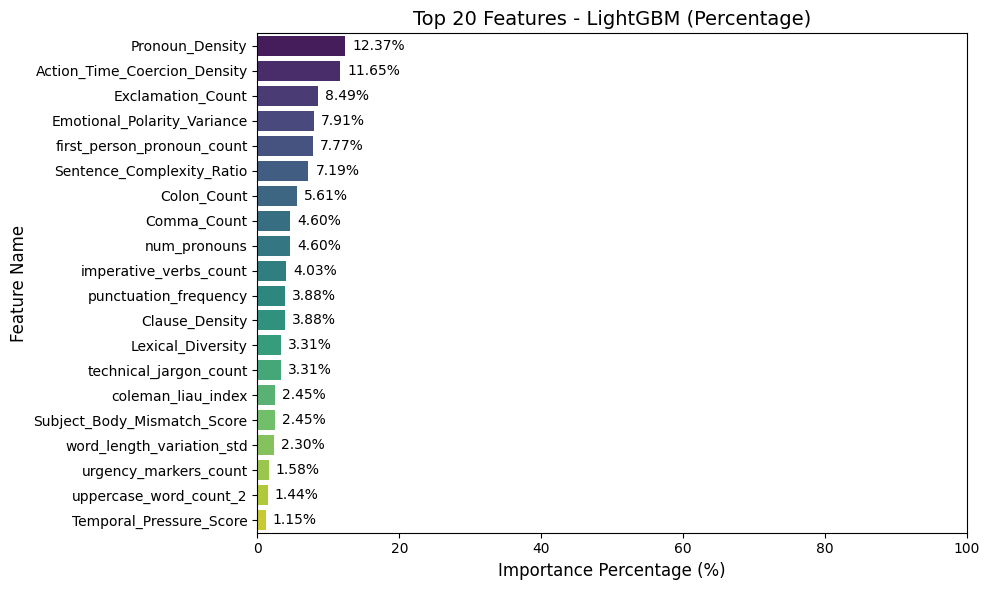


--- 📈 แสดงผลกราฟ Top Features สำหรับ LightGBM (โดยใช้ plt.show()) ---

✅ Pipeline การวิเคราะห์และการประเมินผลโมเดลเสร็จสมบูรณ์


In [114]:
# ==========================================================
# 5. # Part 4 : Main script – Run pipeline
# ==========================================================
if __name__ == "__main__":

    # 1. โหลดข้อมูล (ใช้ข้อมูลทั้งหมดเป็น Training Set สำหรับ Final Model)
    DATA_PATH = "train.csv"
    try:
        df = load_email_csv(DATA_PATH)
    except FileNotFoundError as e:
        print(f"🛑 ข้อผิดพลาดร้ายแรง: ไม่พบไฟล์ข้อมูล {DATA_PATH} ({e})")
        exit()

    # 2. สร้าง DataFrame ฟีเจอร์
    print("\n--- 1. Feature Engineering ---")
    feature_df = build_feature_dataframe(df)

    # 3. เตรียม X และ y (ใช้ข้อมูลทั้งหมดเป็นชุดฝึกเต็ม)
    X_full, y_full, feature_cols = prepare_X_y(feature_df, label_col="Label")
    print(f"✅ ข้อมูลพร้อมสำหรับการฝึกโมเดล: X shape={X_full.shape}, Phishing rate={y_full.mean():.2f}")

    # 4. แบ่งข้อมูลสำหรับ Tuning (X_train, y_train = 80%)
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
    )
    base_models = get_models()

    # ==========================================================
    # 📌 RUN 1 & RUN 2: TRAINING & OPTUNA TUNING EXECUTION
    # ==========================================================
    print("\n" + "="*80)
    print("RUN 1: 🧠 FINAL BASELINE TRAINING (ON X_full)")
    print("="*80)
    final_trained_models = train_and_evaluate_final_models(X_full, y_full, base_models)

    print("\n" + "="*80)
    print("RUN 2: ✨ OPTUNA HYPERPARAMETER TUNING (Using X_train)")
    print("="*80)

    tuned_models_dict = {}
    best_params_dict = {}

    for name in base_models.keys():
        try:
            tuned_model, best_params = tune_model_with_optuna(name, X_train, y_train, n_trials=30)
            tuned_models_dict[name] = tuned_model
            best_params_dict[name] = best_params
        except Exception as e:
            print(f"🛑 Error tuning {name}: {e}")
            tuned_models_dict[name] = base_models[name]

    # ==========================================================
    # 📌 RUN 3: EVALUATION ON UNSEEN DATA
    # ==========================================================
    UNSEEN_DATA_PATH = "test.csv"

    # 3.1 Get Unseen Data and BASELINE Metrics
    df_base_metrics, cm_base_dfs, X_unseen, y_unseen = evaluate_unseen_test_data_pipeline(
        final_trained_models,
        UNSEEN_DATA_PATH
    )

    # 3.2 Evaluate Tuned Models on Unseen Data (Standard Threshold 0.5)
    print("\n✅ Calculating Metrics for Tuned Models on Unseen Data...")
    df_tuned_metrics, cm_tuned_dfs = evaluate_all_models_split(
        tuned_models_dict,
        X_unseen,
        y_unseen
    )

    # ----------------------------------------------------------
    # 🎯 3.3 THRESHOLD OPTIMIZATION & RE-EVALUATION (New Step)
    # ----------------------------------------------------------
    print("\n" + "="*80)
    print("RUN 3.3: 🎯 THRESHOLD OPTIMIZATION (Maximizing F1 on X_train)")
    print("="*80)

    df_tuned_opt_metrics_list = []

    # ✅ FIX: การจัดการ Index ให้เริ่มที่ 1
    # ใช้วิธีการวนลูปเดิม แต่ต้องมั่นใจว่าฟังก์ชัน evaluate_model_with_threshold
    # ถูกแก้ไขให้รับ 'name' เป็น argument แรก

    for name, model in tuned_models_dict.items():
        # 1. หา Optimal Threshold จากชุดข้อมูล Training (X_train)
        optimal_threshold = find_optimal_threshold(model, X_train, y_train)

        # 2. Re-Evaluate บน Unseen Data (X_unseen, y_unseen) ด้วย Threshold ใหม่
        # NOTE: ต้องใช้ evaluate_model_with_threshold(name, model, ...)
        metrics, cm = evaluate_model_with_threshold(name, model, X_unseen, y_unseen, optimal_threshold)

        # เพิ่มข้อมูล Threshold
        metrics['Optimal_Threshold'] = optimal_threshold
        df_tuned_opt_metrics_list.append(metrics)

        print(f"✅ {name}: Optimal Threshold={optimal_threshold:.4f}, New F1={metrics['F1']:.4f}")

    df_tuned_opt_metrics = pd.DataFrame(df_tuned_opt_metrics_list)
    # ✅ FIX: กำหนด Index ให้เริ่มที่ 1
    df_tuned_opt_metrics.index = df_tuned_opt_metrics.index + 1

    # ==========================================================
    # 📌 RUN 4: CONSOLIDATE AND DISPLAY FINAL RESULTS
    # ==========================================================

    # 1. Format BASE Metrics Table (ตาราง 1)
    df_base_display = df_base_metrics[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].rename(
        columns={'Accuracy': 'Base_Accuracy', 'Precision': 'Base_Precision', 'Recall': 'Base_Recall', 'F1': 'Base_F1', 'AUC': 'Base_AUC'}
    )

    # 2. Format TUNED Metrics Table (ตาราง 2)
    df_tuned_display = df_tuned_metrics[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].rename(
        columns={'Accuracy': 'Tuned_Accuracy', 'Precision': 'Tuned_Precision', 'Recall': 'Tuned_Recall', 'F1': 'Tuned_F1', 'AUC': 'Tuned_AUC'}
    )

    # 3. Format OPTIMIZED Metrics Table (ตาราง 3)
    df_opt_display = df_tuned_opt_metrics[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'Optimal_Threshold']].rename(
        columns={'Accuracy': 'Opt_Accuracy', 'Precision': 'Opt_Precision', 'Recall': 'Opt_Recall', 'F1': 'Opt_F1', 'AUC': 'Opt_AUC'}
    )


    print("\n" + "="*120)
    print("🏆 FINAL COMPARISON: PERFORMANCE ON UNSEEN TEST DATA")
    print("="*120)

    # --- ตาราง 1: BASELINE (NON-TUNED) ---
    print("\n--- 🥇 BASELINE (NON-TUNED) METRICS ---")
    print(df_base_display.to_markdown(index=False))

    # --- ตาราง 2: TUNED (Threshold 0.5) ---
    print("\n--- 🥈 TUNED (POST-OPTUNA - THRESHOLD 0.5) METRICS ---")
    print(df_tuned_display.to_markdown(index=False))

    # --- ตาราง 3: OPTIMIZED (Threshold Adjusted) ---
    print("\n--- 🥉 OPTIMIZED (THRESHOLD CALIBRATED) METRICS ---")
    print("NOTE: นี่คือประสิทธิภาพที่คาดหวังเมื่อใช้ Optimal Threshold ที่หาได้จาก X_train.")
    print(df_opt_display.to_markdown(index=False))

    # 4. แสดงค่า Hyperparameter ที่ดีที่สุด
    print("\n" + "="*120)
    print("✨ OPTUNA RESULTS: BEST HYPERPARAMETERS FOUND")
    print("="*120)

    for name, params in best_params_dict.items():
        print(f"\n--- 🌟 {name} ---")
        for k, v in params.items():
            print(f"  {k}: {v}")

    # 5. แสดงกราฟ Top Features (ใช้โมเดล Base)
    print("\n" + "="*120)
    print("🔥 RUN 5: TOP FEATURE ANALYSIS (Horizontal Bar Chart)")
    print("="*120)
    for name, model in final_trained_models.items():
        display_top_features(name, model, X_full, top_n=20)

    print("\n✅ Pipeline การวิเคราะห์และการประเมินผลโมเดลเสร็จสมบูรณ์")